In [ ]:
# Sector Allocation Analysis

## Objective
- Aggregate sector weights across all equity funds.
- Visualize sector allocation using a Donut Chart.

In [1]:
## Import Libraries
import pandas as pd
import plotly.express as px

In [2]:
# Load Dataset
df = pd.read_csv("../data/processed/09_portfolio_holdings_clean.csv")

In [3]:
# Check Dataset
print(df.shape)

print(df.columns)

df.head()

(322, 8)
Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [4]:
# Aggregate Sector Weights
sector_df = (
    df.groupby("sector")["weight_pct"]
      .sum()
      .reset_index()
      .sort_values(by="weight_pct", ascending=False)
)

sector_df

,sector,weight_pct
1,Banking,652.26
7,IT,455.47
11,Pharma,407.45
0,Automobile,323.65
13,Utilities,265.54
6,FMCG,229.11
8,Infrastructure,192.16
4,Diversified,169.23
12,Telecom,145.62
3,Consumer Goods,127.61


In [6]:
# Create Donut Chart
fig = px.pie(
    sector_df,
    names="sector",
    values="weight_pct",
    hole=0.5,
    title="Sector Allocation Across Equity Mutual Funds"
)

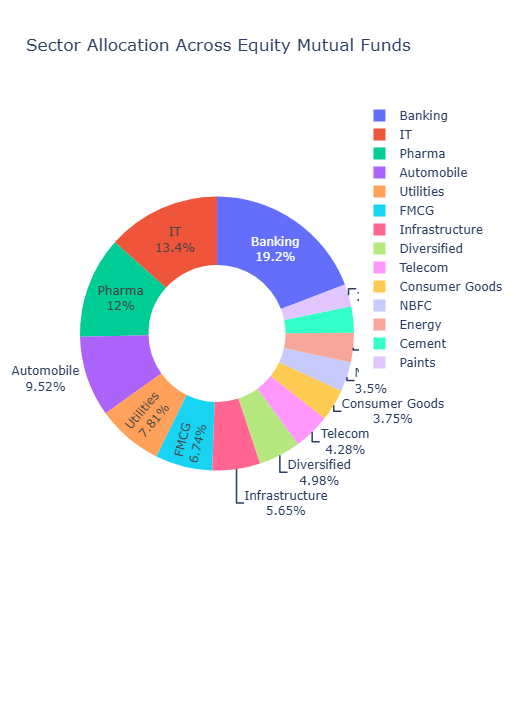

In [7]:
# Improve Layout
fig.update_traces(
    textinfo="percent+label"
)

fig.update_layout(
    template="plotly_white",
    height=700,
    width=900
)

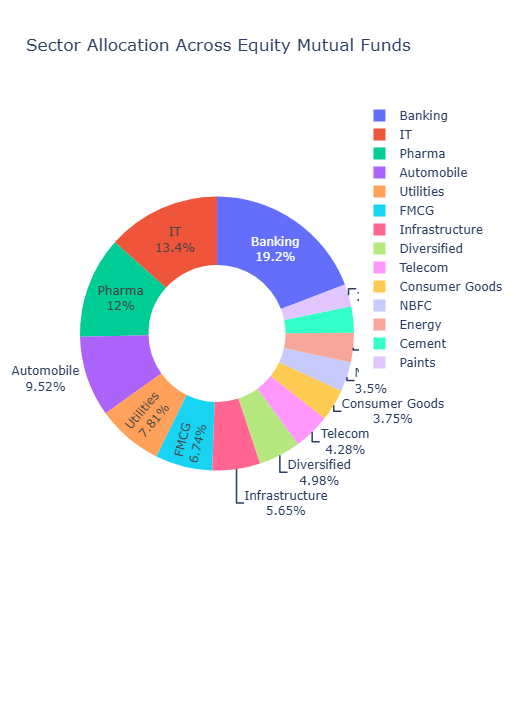

In [8]:
# Show Chart
fig.show()

In [10]:
# Save Html Report
fig.write_html("../reports/12_sector_allocation_donut.html")